# HASVD with real datas : KEMAR MIT dataset

In [1]:
import numpy as np
from time import time

data = np.load("../../../art_data/KEMAR.npy", allow_pickle=True).item(0)

ir = data['ir']

ir=np.concatenate((ir, np.zeros_like(ir)[1:]))

n, p, m = ir.shape

s=int((n+1)/2)

print(f'number of samples s :\t{s}')
print(f'number of outputs p:\t{p}')
print(f'number of inputs m:\t{m}')

# NOTE: for notation purposes, we will reuse n,m. so be wary of this change in variables.

number of samples s :	256
number of outputs p:	2
number of inputs m:	710


## Hankel scalar matrix

We generate Hankel scalar matrix by picking samples reading for a specific input and output.

In [2]:
from hasvd.utils.matrix import array_to_hankel

i,j = (0,5)               # ith output and mth input
assert i<p and j<m, "index exceeds output/input size"

sequence = ir[:,i,j]

A = array_to_hankel(sequence, (s,s))

print("Matrix shape:", A.shape)
print("Matrix rank check:", np.linalg.matrix_rank(A))

Matrix shape: (256, 256)
Matrix rank check: 253


Start with a truncated SVD with tolerance `tol`, where `tol` is the truncation in terms of the Frobenius norm error.

In [3]:
tol = 1e-8

from hasvd.utils.svd import svd_with_tol, method_of_snapshots

svd_method =svd_with_tol

print("\u0332".join("LAPACK gesdd"))
# SVD of the whole matrix
start = time()
U, E, Vh = svd_method(
    A,
    full_matrices=False,
    truncate_tol=tol,
)
duration = time()-start
print("Error:", np.linalg.norm(A - U @ np.diag(E) @ Vh))
print("Runtime:", duration," seconds")
print("Rank of U*S*Vt:", np.linalg.matrix_rank(U @ np.diag(E) @ Vh), "\n")

L̲A̲P̲A̲C̲K̲ ̲g̲e̲s̲d̲d
Error: 4.9155767922297976e-11
Runtime: 0.0988454818725586  seconds
Rank of U*S*Vt: 251 



Now we will perform HASVD with the same tolerance, but control parameter $\omega$=`omega`. We also set partitions of blocks (`M`,`Ǹ`).

In [169]:
omega = 0.1
M,N=2,4         # Partitions blocks
m,n=int(s/M),int(s/N)

print("Block shape:", "(", m, ",", n, ")")
print("Block partitions:", "(", M, ",", N, ")\n")
print("Control parameter ω:", omega)

Block shape: ( 128 , 64 )
Block partitions: ( 2 , 4 )

Control parameter ω: 0.1


In here we will be using two-level bidirectional trees. We start with creating a tree using routines in the `hasvd.utils.trees`. We here should define the direction of aggregation as well.

This will generate a `hasvd_Node` object, which defines a tree. From this you can construct any tree. To check that the aggregation shape of your tree is consistent, use the `assert_shape_consistency` method.

In [170]:
from hasvd.utils.trees import tlbd_dist_hasvd_tree, tlbd_inc_hasvd_tree, assert_shape_consistency

outer_direction = 0     # Direction of the root-level aggregation
tree_choice = 1         # Choice of tree: 0 distributed, 1 incremental

match outer_direction:
    case 0:
        num_outer_slices=N
        num_inner_slices=M
    case 1:
        num_outer_slices=M
        num_inner_slices=N

trees = [tlbd_dist_hasvd_tree(num_outer_slices,num_inner_slices,outer_direction,(m,n)),tlbd_inc_hasvd_tree(num_outer_slices,num_inner_slices,outer_direction,(m,n))]

for tree in trees:
    assert_shape_consistency(tree)

tree = trees[tree_choice]
print(tree) # Print to check shape of tree if necessary.

c r [256x256]
+-r 9 [256x64]
| +-l 0 [128x64]
| +-l 1 [128x64]
+-c 10 [256x192]
  +-r 11 [256x64]
  | +-l 2 [128x64]
  | +-l 3 [128x64]
  +-c 12 [256x128]
    +-r 13 [256x64]
    | +-l 4 [128x64]
    | +-l 5 [128x64]
    +-r 14 [256x64]
      +-l 6 [128x64]
      +-l 7 [128x64]


We now build a block-to-leaf mapping to connect the matrix to the tree using our map generators in `hasvd.utils.trees`. 

We should also prescribe nodal errors. This is given in `hasvd.utils.errors`.

Then we can perform the HASVD using the `hasvd.utils.svd.hasvd`. In here we can also track ranks connected to a node by setting `track_ranks=True`.

In [171]:
from hasvd.utils.trees import tlbd_general_btl_map,branch_node_count, non_leaf_count
from hasvd.utils.errors import tight_error,naive_error

btl_map = tlbd_general_btl_map(A,M,N,m,n,outer_direction)   # Makes a map to block of a node
error_choice = 0                                            # Choice of error_prescription: 0 naive, 1 tight

nodal_errors = [lambda node : tight_error(
            node,
            tol,
            omega,
            branch_node_count(tree),
        ),lambda node : naive_error(
            node,
            tol,
            omega,
            non_leaf_count(tree),
        )]
nodal_error=nodal_errors[error_choice]

Time to run the HASVD!

In [172]:
from hasvd.utils.svd import hasvd

print("\u0332".join("HASVD"))
# SVD of the whole matrix
start = time()
U, E, Vh, rank_dict = hasvd(tree,btl_map,nodal_error,svd_method=svd_method, track_ranks=True)
duration = time()-start
print("Error:", np.linalg.norm(A - U @ np.diag(E) @ Vh))
print("Runtime:", duration," seconds")
print("Rank of U*S*Vt:", np.linalg.matrix_rank(U @ np.diag(E) @ Vh), "\n")

H̲A̲S̲V̲D
Error: 4.811223548398129e-10
Runtime: 1.7278659343719482  seconds
Rank of U*S*Vt: 251 



Rank plot:

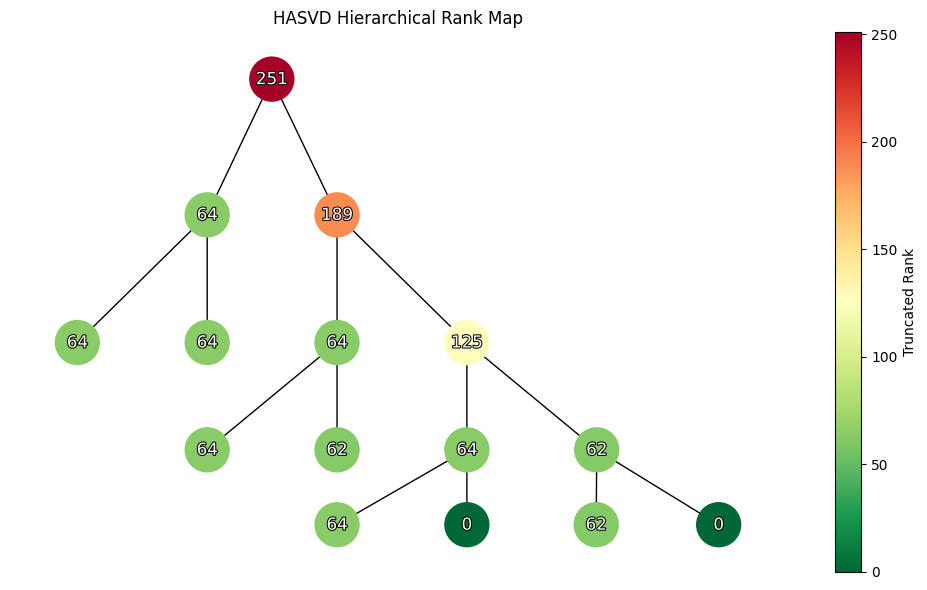

In [173]:
from hasvd.utils.trees import plot_rank_graph

plot_rank_graph(tree,rank_dict)

## Hankel block structures

We now construct the Hankel block structure.

In [13]:
from hasvd.utils.matrix import block_array_to_block_hankel

s=256

H = block_array_to_block_hankel(ir[:2*s-1],(s,s))

for i in range(s):
    for j in range(s):
        assert np.allclose(H[i*ir.shape[1]:(i+1)*ir.shape[1]
                             ,j*ir.shape[2]:(j+1)*ir.shape[2]],ir[i+j])

print("Matrix shape:", H.shape)
print("Matrix rank check:", np.linalg.matrix_rank(H))

Matrix shape: (512, 181760)
Matrix rank check: 512


In [14]:
from hasvd.utils.svd import svd_with_tol, method_of_snapshots

tol = 1e-1*np.linalg.norm(H)
omega = 0.5
L=32
M,N=int(s/L),int(s/L)         # Partitions blocks
m,n= ir.shape[1]*L,ir.shape[2]*L
check_lapack = True

svd_method=svd_with_tol

In [ ]:




if check_lapack:
    print("\u0332".join("LAPACK gesdd"))
    # SVD of the whole matrix
    start = time()
    U, Et, Vh = svd_method(
        H,
        full_matrices=False,
        truncate_tol=tol,
    )
    duration = time()-start
    print("Error:", np.linalg.norm(H - U @ np.diag(Et) @ Vh))
    print("Runtime:", duration," seconds")
    print("Rank of U*S*Vt:", np.linalg.matrix_rank(U @ np.diag(Et) @ Vh), "\n")
    


L̲A̲P̲A̲C̲K̲ ̲g̲e̲s̲d̲d
Error: 26.39373364978167
Runtime: 35.39576864242554  seconds
Rank of U*S*Vt: 90 



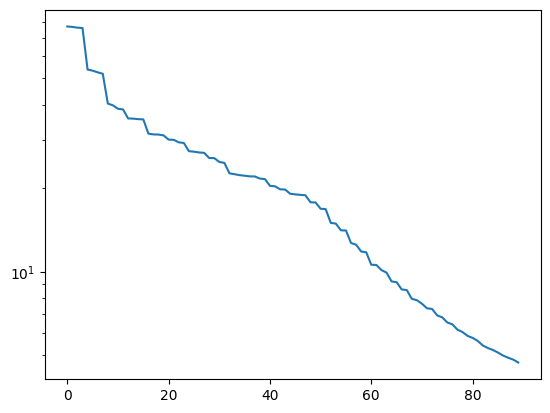

In [16]:
import matplotlib.pyplot as plt

plt.semilogy(Et)

Tree construction:

In [17]:
from hasvd.utils.trees import tlbd_dist_hasvd_tree, tlbd_inc_hasvd_tree, assert_shape_consistency

outer_direction = 0     # Direction of the root-level aggregation
tree_choice = 0         # Choice of tree: 0 distributed, 1 incremental


match outer_direction:
    case 0:
        num_outer_slices=N
        num_inner_slices=M
    case 1:
        num_outer_slices=M
        num_inner_slices=N

trees = [tlbd_dist_hasvd_tree(num_outer_slices,num_inner_slices,outer_direction,(m,n)),tlbd_inc_hasvd_tree(num_outer_slices,num_inner_slices,outer_direction,(m,n),)]

for tree in trees:
    assert_shape_consistency(tree)

tree = trees[tree_choice]
#print(tree)

Error prescription:

In [18]:
from hasvd.utils.trees import tlbd_general_btl_map,tlbd_hankelblockarray_btl_map,branch_node_count, non_leaf_count
from hasvd.utils.errors import tight_error,naive_error


btl_map = tlbd_general_btl_map(H, M, N, m, n,outer_direction)   # Makes a map to block of a node
error_choice = 0                                            # Choice of error_prescription: 0 tight, 1 naive

nodal_errors = [lambda node : tight_error(
            node,
            tol,
            omega,
            branch_node_count(tree),
        ),lambda node : naive_error(
            node,
            tol,
            omega,
            non_leaf_count(tree),
        )]
nodal_error=nodal_errors[error_choice]

HASVD of block Hankel structure

In [ ]:
from hasvd.utils.svd import hasvd, simple_cache_map


print("\u0332".join("HASVD Block Hankel structure"))
print("Block partitions:", "(", M, ",", N, ")\n")
print("Control parameter ω:", omega)
# SVD of the whole matrix
start = time()
U, E, Vh, rank_dict = hasvd(tree,btl_map,nodal_error,svd_method=svd_method,track_ranks=True)
duration = time()-start
print("Error:", np.linalg.norm(H - U @ np.diag(E) @ Vh))
print("Runtime:", duration," seconds")
print("Rank of U*S*Vt:", np.linalg.matrix_rank(U @ np.diag(E) @ Vh), "\n")

H̲A̲S̲V̲D̲ ̲B̲l̲o̲c̲k̲ ̲H̲a̲n̲k̲e̲l̲ ̲s̲t̲r̲u̲c̲t̲u̲r̲e
Block partitions: ( 8 , 8 )

Control parameter ω: 0.5
Error: 14.277620793873592
Runtime: 25.112736701965332  seconds
Rank of U*S*Vt: 137 



In [ ]:
import matplotlib.pyplot as plt

plt.semilogy(E)
if check_lapack:
    plt.semilogy(Et)

plt.xlabel("i")
plt.ylabel("$\\sigma_i$")
  